<a href="https://colab.research.google.com/github/sadmansalvi/-GovernmentDecisionSupport/blob/main/WBProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
# Cell 1: Setup & Data Fetching (1990-2019)
!pip install wbdata pmdarima pandas numpy scikit-learn tensorflow xgboost statsmodels

import wbdata
import pandas as pd
import numpy as np
import tensorflow as tf
import xgboost as xgb
from pmdarima import auto_arima
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.optimizers import Adam
import datetime
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

# 1. Country List
countries = ["USA", "JPN", "DEU", "GBR", "IND", "FRA", "ITA", "CAN", "KOR", "BRA", "MEX"]

indicators = {
    "NE.CON.GOVT.KD.ZG": "Gov_Expenditure",
    "NE.CON.PRVT.KD.ZG": "Consumption",
    "NE.GDI.TOTL.KD.ZG": "Investment",
    "NE.IMP.GNFS.KD.ZG": "Imports",
    "NE.EXP.GNFS.KD.ZG": "Exports"
}

# 2. Fetch Data (Stopping at 2019)
print("Fetching data from 1990 to 2019...")
data_date = (datetime.datetime(1990, 1, 1), datetime.datetime(2020, 1, 1))
df = wbdata.get_dataframe(indicators, country=countries, date=data_date)

# 3. Clean & Repair
df.reset_index(inplace=True)
df['date'] = df['date'].astype(int)
df = df.sort_values(by=['country', 'date'])
df_clean = df.groupby('country').apply(lambda x: x.ffill().bfill()).reset_index(drop=True).dropna()

print(f"Data Loaded. Total Rows: {len(df_clean)}")

Fetching data from 1990 to 2019...
Data Loaded. Total Rows: 341


In [62]:
# Cell 2: Preprocessing
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_clean[list(indicators.values())])

# Parameters
n_past = 4
n_future = 1
n_features = 5

X, y, dates, countries_idx = [], [], [], []

for country in df_clean['country'].unique():
    indices = df_clean[df_clean['country'] == country].index
    if len(indices) < n_past + n_future: continue

    start = df_clean.index.get_loc(indices[0])
    end = df_clean.index.get_loc(indices[-1])
    c_data = scaled_data[start : end + 1]
    c_dates = df_clean.iloc[start : end + 1]['date'].values

    for i in range(n_past, len(c_data) - n_future + 1):
        X.append(c_data[i - n_past : i, :])
        y.append(c_data[i + n_future - 1, 0])
        dates.append(c_dates[i + n_future - 1])
        countries_idx.append(country)

X = np.array(X)
y = np.array(y)
dates = np.array(dates)
countries_idx = np.array(countries_idx)

# Flatten X for SVR and XGBoost (2D input required)
X_flat = X.reshape(X.shape[0], -1)

print(f"Sequences Created: {len(X)}")

Sequences Created: 297


In [63]:
# Cell 3: Model Definitions

# --- 1. Statistical & ML Models ---
def run_stat_ml_models(model_name, train_idx, test_idx):
    preds, actuals = [], []
    X_train_f, X_test_f = X_flat[train_idx], X_flat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    if model_name == "ARIMA":
        # ARIMA runs per country
        for c in np.unique(countries_idx[test_idx]):
            c_mask_train = (countries_idx == c) & train_idx
            c_mask_test = (countries_idx == c) & test_idx
            train_data, test_data = y[c_mask_train], y[c_mask_test]
            if len(test_data) == 0: continue
            try:
                model = auto_arima(train_data, seasonal=False, error_action='ignore', suppress_warnings=True)
                preds.extend(model.predict(n_periods=len(test_data)))
                actuals.extend(test_data)
            except: continue

    elif model_name == "ETS":
        for c in np.unique(countries_idx[test_idx]):
            c_mask_train = (countries_idx == c) & train_idx
            c_mask_test = (countries_idx == c) & test_idx
            train_data, test_data = y[c_mask_train], y[c_mask_test]
            if len(train_data) < 2 or len(test_data) == 0: continue
            try:
                model = ExponentialSmoothing(train_data, trend='add', seasonal=None).fit()
                preds.extend(model.forecast(len(test_data)))
                actuals.extend(test_data)
            except: continue

    elif model_name == "SVR":
        model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
        model.fit(X_train_f, y_train)
        preds = model.predict(X_test_f)
        actuals = y_test

    elif model_name == "XGBOOST":
        model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.01, max_depth=5)
        model.fit(X_train_f, y_train)
        preds = model.predict(X_test_f)
        actuals = y_test

    return np.array(actuals), np.array(preds)

# --- 2. Deep Learning Models ---
def build_dl_model(model_name, input_shape):
    model = tf.keras.Sequential()
    if model_name == "CNN":
        model.add(tf.keras.layers.Conv1D(200, 1, activation='relu', input_shape=input_shape))
        model.add(tf.keras.layers.MaxPooling1D(2))
        model.add(tf.keras.layers.Flatten())
        model.add(tf.keras.layers.Dense(100, activation='relu'))
        model.add(tf.keras.layers.Dense(1))
    elif model_name == "LSTM":
        model.add(tf.keras.layers.LSTM(200, return_sequences=True, input_shape=input_shape))
        model.add(tf.keras.layers.Dropout(0.2))
        model.add(tf.keras.layers.LSTM(200, return_sequences=False))
        model.add(tf.keras.layers.Dropout(0.2))
        model.add(tf.keras.layers.Dense(1))
    elif model_name == "GRU":
        model.add(tf.keras.layers.GRU(200, return_sequences=True, input_shape=input_shape))
        model.add(tf.keras.layers.Dropout(0.2))
        model.add(tf.keras.layers.GRU(200, return_sequences=False))
        model.add(tf.keras.layers.Dropout(0.2))
        model.add(tf.keras.layers.Dense(1))

    model.compile(optimizer=Adam(learning_rate=0.004), loss='mean_squared_error')
    return model

def run_dl_model(model_name, train_idx, test_idx):
    X_train_seq, y_train = X[train_idx], y[train_idx]
    X_test_seq, y_test = X[test_idx], y[test_idx]

    model = build_dl_model(model_name, (n_past, n_features))
    # Using 50 epochs for efficiency
    model.fit(X_train_seq, y_train, epochs=50, batch_size=256, verbose=0)

    preds = model.predict(X_test_seq)
    return y_test.flatten(), preds.flatten()

In [66]:
# Cell 4: Running the Analysis (Scaled Metrics Only)
model_list = ["ARIMA", "ETS", "SVR", "XGBOOST", "CNN", "LSTM", "GRU"]
results = []

def safe_mape_scaled(y_true, y_pred):
    # Avoid division by zero in scaled data (add epsilon)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-6))) * 100

print(">>> RUNNING FORECASTS (Test Period: 2016-2019)")
print("Training Data: 1990-2015")

# Split Masks
train_mask = dates <= 2015
test_mask = (dates > 2015) & (dates <= 2019)

for m in model_list:
    print(f"Running {m}...", end=" ")

    # 1. Run Model (Returns Scaled predictions)
    if m in ["ARIMA", "ETS", "SVR", "XGBOOST"]:
        act_scaled, pred_scaled = run_stat_ml_models(m, train_mask, test_mask)
    else:
        act_scaled, pred_scaled = run_dl_model(m, train_mask, test_mask)

    # 2. Calculate All Metrics (Scaled)
    mape_val = safe_mape_scaled(act_scaled, pred_scaled)
    mae_val = mean_absolute_error(act_scaled, pred_scaled)
    rmse_val = np.sqrt(mean_squared_error(act_scaled, pred_scaled))

    results.append({
        "Model": m,
        "MAPE (%)": mape_val,
        "MAE": mae_val,
        "RMSE": rmse_val
    })
    print(f"Done.")

>>> RUNNING FORECASTS (Test Period: 2016-2019)
Training Data: 1990-2015
Running ARIMA... Done.
Running ETS... Done.
Running SVR... Done.
Running XGBOOST... Done.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
Done.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 288ms/step
Done.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 339ms/step
Done.


In [67]:
# Cell 5: Final Results
df_results = pd.DataFrame(results)

print("\n=====================================================================")
print("FINAL PROJECT RESULTS (Stable Era: 1990-2019)")
print("=====================================================================")

# Display Clean Result Table sorted by MAPE
print(df_results[['Model', 'MAE', 'RMSE', 'MAPE (%)']].sort_values(by='MAPE (%)'))


FINAL PROJECT RESULTS (Stable Era: 1990-2019)
     Model       MAE      RMSE   MAPE (%)
1      ETS  0.035899  0.048715  10.968912
0    ARIMA  0.042112  0.055777  13.417967
3  XGBOOST  0.049044  0.071894  14.030539
4      CNN  0.051844  0.076329  14.151338
5     LSTM  0.050926  0.077233  14.201765
6      GRU  0.051525  0.072345  15.422691
2      SVR  0.060626  0.082089  17.649039


Generating Master Comparison Plot (All 7 Models)...
Forecasting ETS... Done.
Forecasting ARIMA... Done.
Forecasting XGBOOST... Done.
Forecasting SVR... Done.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Done.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step
Done.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 345ms/step
Done.


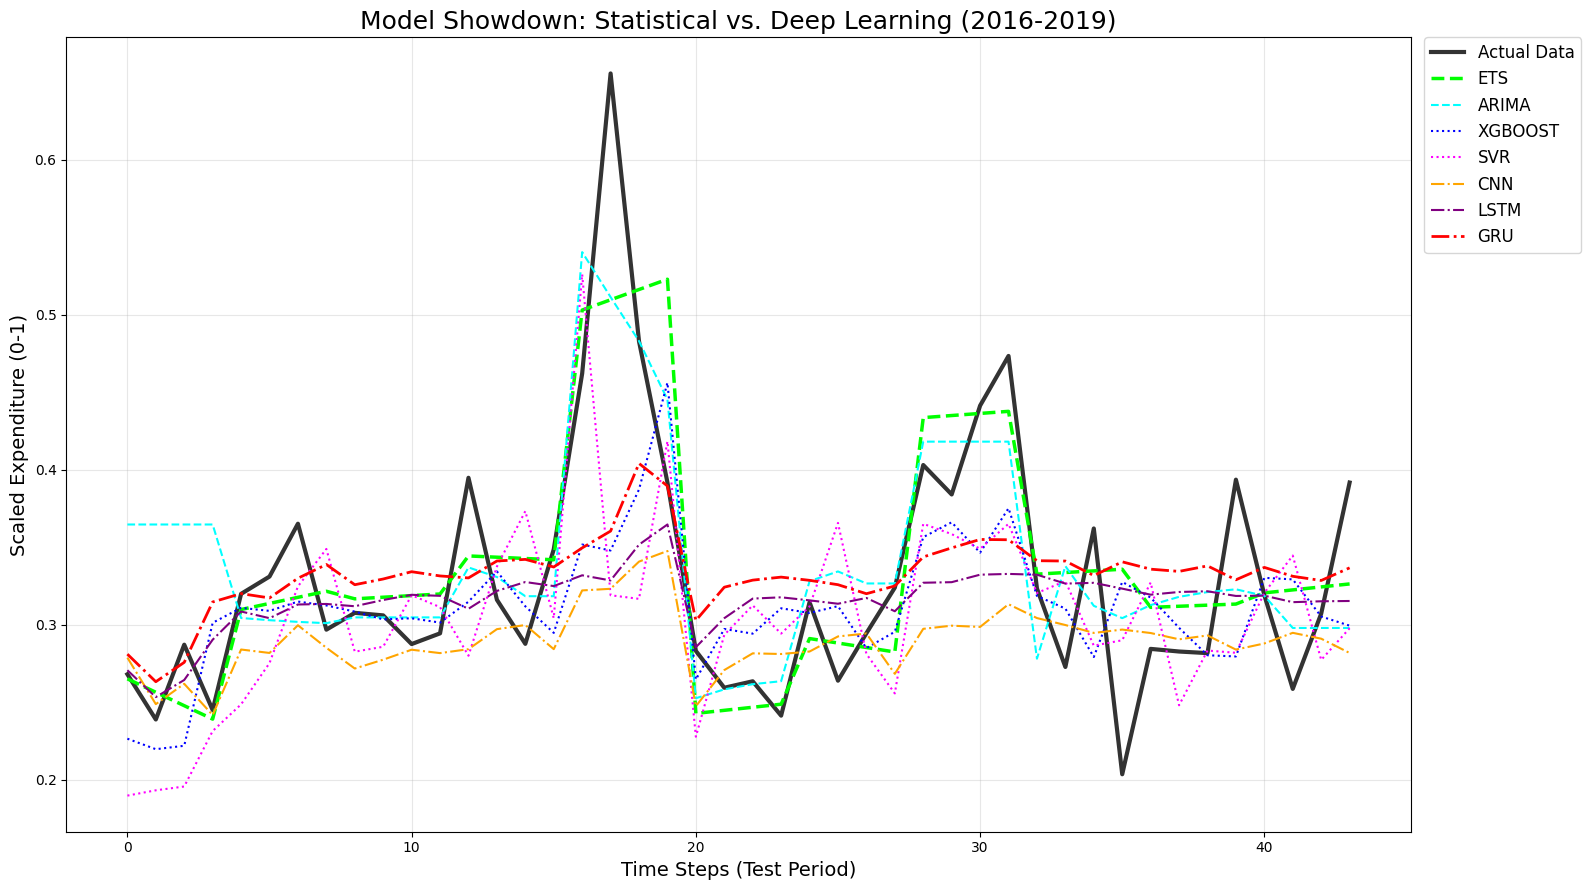

In [70]:
# Cell 6: Visualizing All Models
import matplotlib.pyplot as plt

print("Generating Master Comparison Plot (All 7 Models)...")

# 1. Setup Timeframe (Test Period: 2016-2019)
train_mask = dates <= 2015
test_mask = (dates > 2015) & (dates <= 2019)
test_dates = range(len(dates[test_mask])) # Simple index for plotting

# Define colors/styles for distinction
model_configs = {
    "ETS":     {"color": "lime",      "style": "--", "width": 2.5}, # The Winner
    "ARIMA":   {"color": "cyan",      "style": "--", "width": 1.5},
    "XGBOOST": {"color": "blue",      "style": ":",  "width": 1.5},
    "SVR":     {"color": "magenta",   "style": ":",  "width": 1.5},
    "CNN":     {"color": "orange",    "style": "-.", "width": 1.5},
    "LSTM":    {"color": "purple",    "style": "-.", "width": 1.5},
    "GRU":     {"color": "red",       "style": "-.", "width": 2.0}  # Paper's Choice
}

plt.figure(figsize=(16, 9))

# 2. Plot Actual Data First (Using ETS run to get 'y_true')
act, _ = run_stat_ml_models("ETS", train_mask, test_mask)
plt.plot(test_dates[:50], act[:50], label='Actual Data', color='black', linewidth=3, alpha=0.8)

# 3. Loop and Plot Every Model
for m in model_configs.keys():
    print(f"Forecasting {m}...", end=" ")

    if m in ["ARIMA", "ETS", "SVR", "XGBOOST"]:
        _, pred = run_stat_ml_models(m, train_mask, test_mask)
    else:
        # Re-run DL models (Training is fast with 50 epochs)
        _, pred = run_dl_model(m, train_mask, test_mask)

    cfg = model_configs[m]
    plt.plot(test_dates[:50], pred[:50],
             label=f"{m}",
             color=cfg['color'],
             linestyle=cfg['style'],
             linewidth=cfg['width'])
    print("Done.")

# 4. Final Formatting
plt.title("Model Showdown: Statistical vs. Deep Learning (2016-2019)", fontsize=18)
plt.xlabel("Time Steps (Test Period)", fontsize=14)
plt.ylabel("Scaled Expenditure (0-1)", fontsize=14)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()